In [3]:
import pandas as pd
import requests
import io
import json
import numpy as np
from fpdf import FPDF
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.dates as md
from fpdf import FPDF
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as ticker
import plotly.graph_objects as go
import plotly.express as px
import plotly.offline as pyo




In [4]:
report_type= 'vessel'
first_Period= '2023'
second_Period= '2024'
#first_period_min= '2023-01-01'
#first_period_max= '2023-12-31'
#second_period_min= '2024-01-01'
#second_period_max= '2024-12-31'
#vessel_name= 'HOSHI - 9453298'
#fleet= 'Fleet 1'
#class_name: null
moving_average= '1'
#moving_average: 1




In [5]:
import json 

text_file_path = 'eeoi_pc_vessel.txt'

# Read the content of the text file and load it into a JSON object
with open(text_file_path, 'r') as file:
    s = json.load(file)  
# Now, you can use the 's' variable to work with your JSON data
print(s)

{'data': {'year1': {'finaldata': [{'cargo_distance': 10506245613, 'cargomt': 656062, 'cargoteu': 0, 'voyages': 4, 'distance': 55056, 'year': '2023', 'mt': 2617612992, 'teu': 0, 'hfo': 0, 'lfo': 5815.78, 'mdo_mgo': 280.34, 'imo': '9625970', 'totalco2': 19009.11, 'totalco2_mt': 19009.11, 'totalco2_kgnm': 0.35, 'equivalent_hfo': 6.4, 'equip_nm': 0, 'eeoi_mt': 1.81, 'eeoi_teu': None, 'fuelkg_nm': 0, 'average_perteu': 0, 'average_permt': 164015.5, 'average_distance': 13764, 'average_fuelcons': 1.6}], 'moving data average': [{'voyage_order': '223.0', 'EEOIGOALMT': 5.07, 'EEOIGOALTEU': None, 'EEOI_MT': 8.85, 'EEOI_TEU': None, 'year': '2023', 'EEOI For Cargo [MT]': 8.85, 'EEOI For Cargo [TEU]': None, 'movingavgmt': 8.85, 'movingavg2mt': None, 'S.No': 1}, {'voyage_order': '226.0', 'EEOIGOALMT': 5.07, 'EEOIGOALTEU': None, 'EEOI_MT': 6.62, 'EEOI_TEU': None, 'year': '2023', 'EEOI For Cargo [MT]': 6.62, 'EEOI For Cargo [TEU]': None, 'movingavgmt': 6.62, 'movingavg2mt': None, 'S.No': 2}, {'voyage_or

In [9]:
import pandas as pd
from datetime import datetime



vsl_name = pd.DataFrame.from_dict(s['vessel_data'])  
col_vsl = dict(zip(vsl_name['imo'], vsl_name['name']))  
if first_Period is None and second_Period is None:  
    date_object_first_Period = datetime.strptime(first_period_max, '%Y-%m-%d')
    first_Period_year = date_object_first_Period.year
    date_object_second_Period = datetime.strptime(second_period_max, '%Y-%m-%d')
    second_Period_year = date_object_second_Period.year
    Heading = "YEAR" + "  " + str(first_Period_year) + " - " + str(second_Period_year) + "  " + "EEOI ANALYSIS"
else:
    Heading = "YEAR" + "  " + first_Period + " - " + second_Period + "  " + "EEOI ANALYSIS"
    first_Period_year, second_Period_year = first_Period, second_Period


# if report_type == 'vessel':
#     # vsl_name = pd.DataFrame.from_dict(s['vessel_data'])
#     # col_vsl = dict(zip(vsl_name['imo'], vsl_name['name']))
#     s = s['data'] 



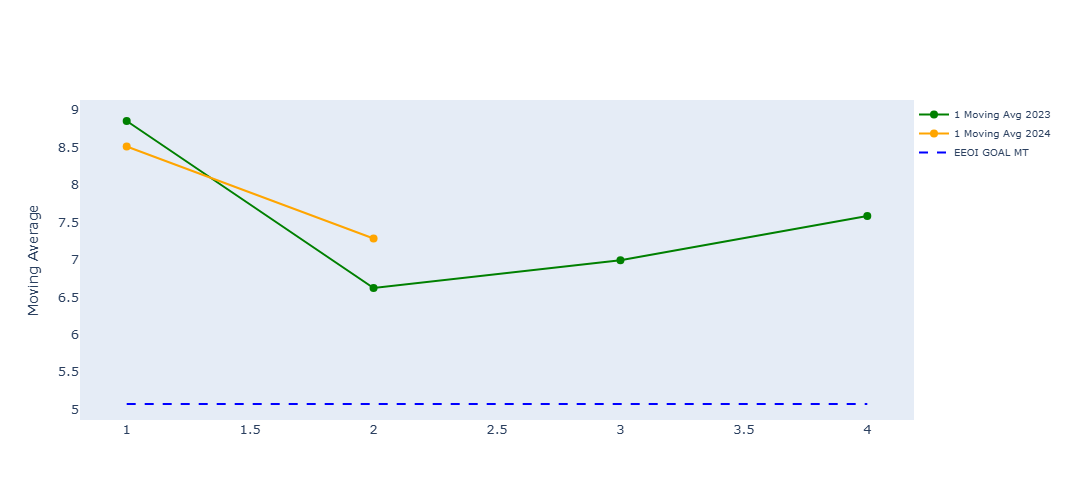

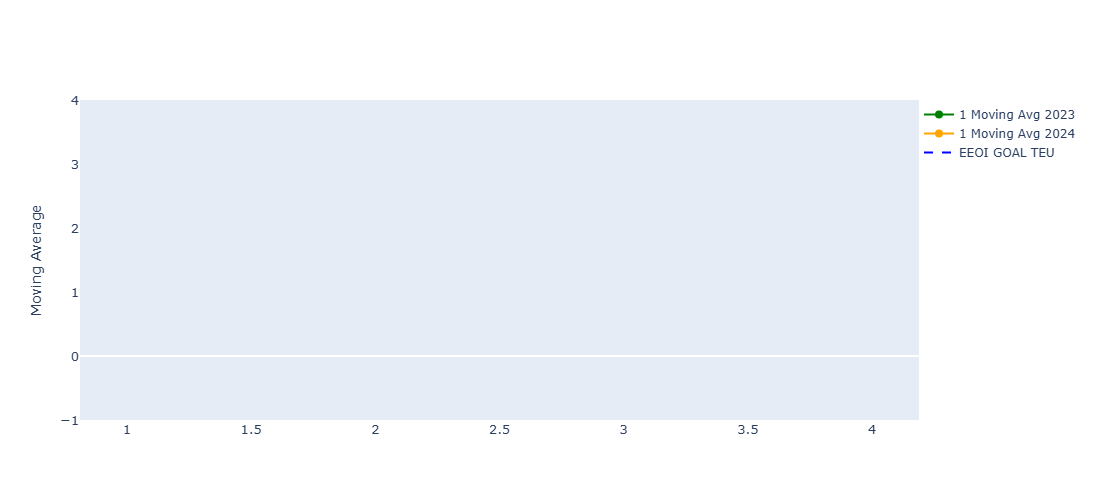

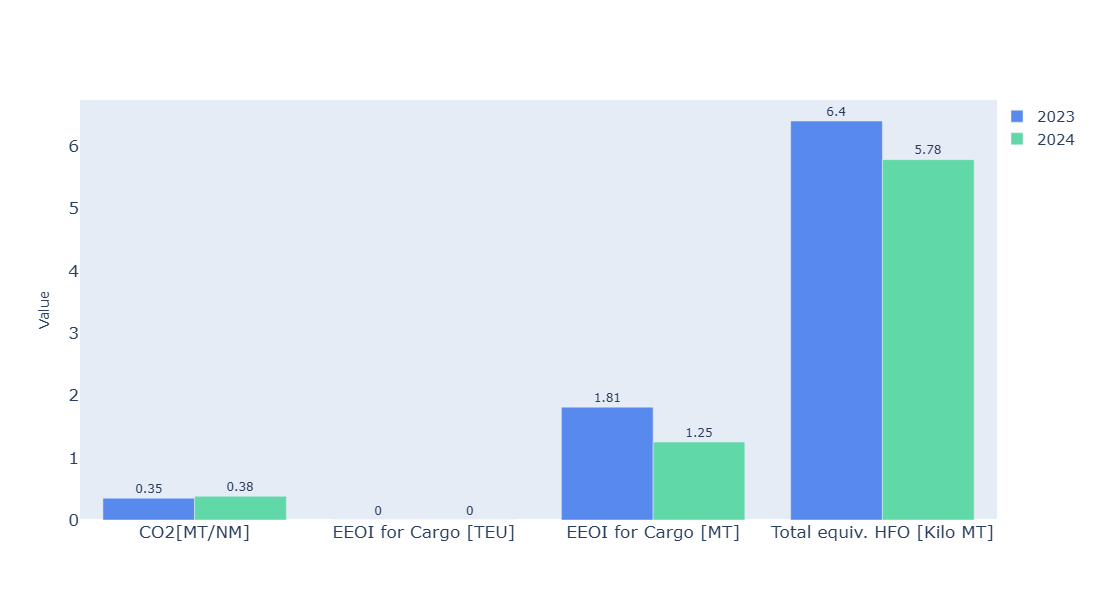

C:\Users\akshaya\AppData\Local\Temp\ipykernel_453696\2495403374.py:262: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



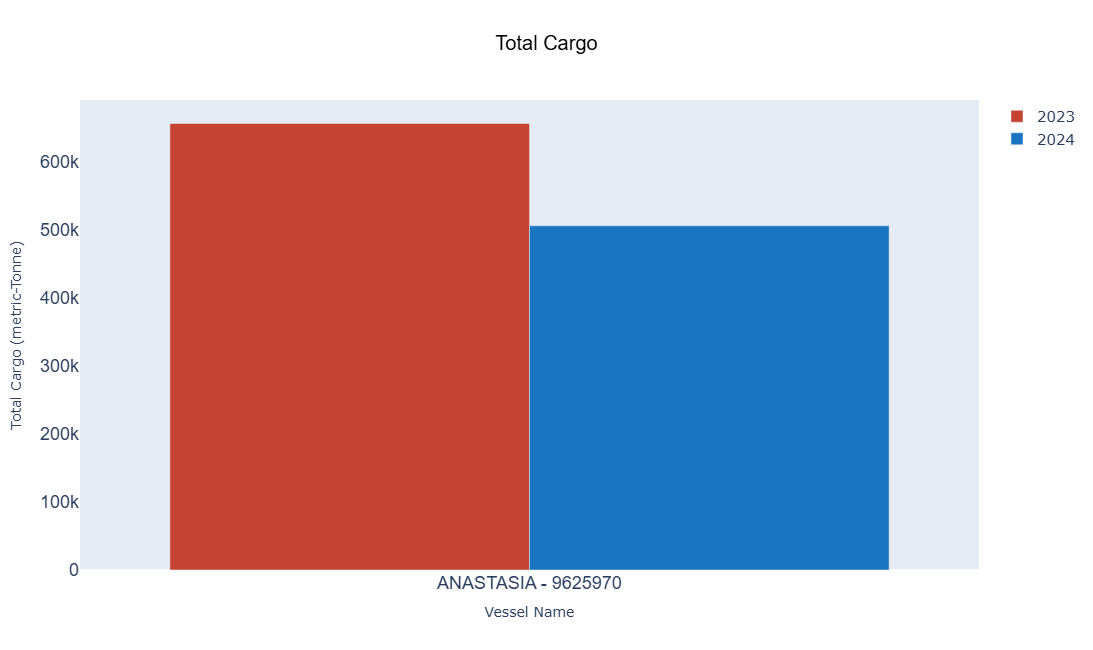

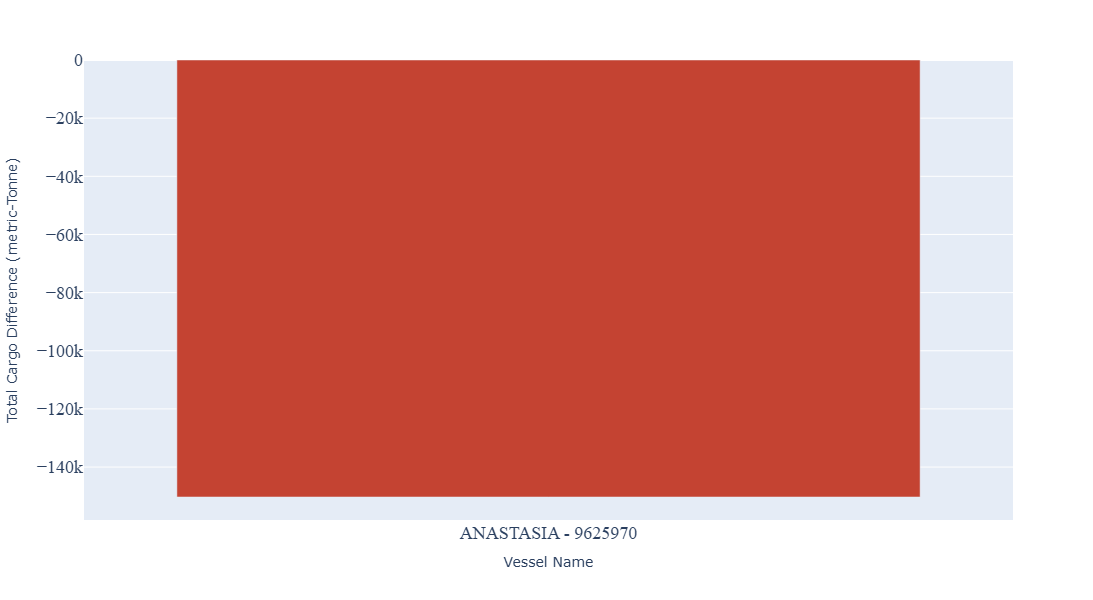

C:\Users\akshaya\AppData\Local\Temp\ipykernel_453696\2495403374.py:354: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



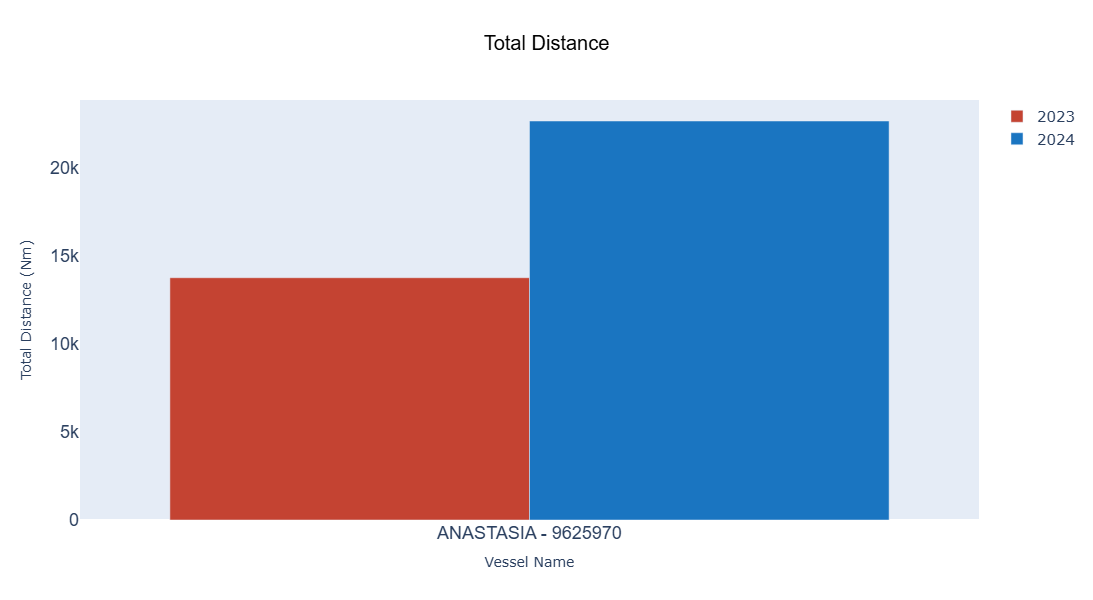

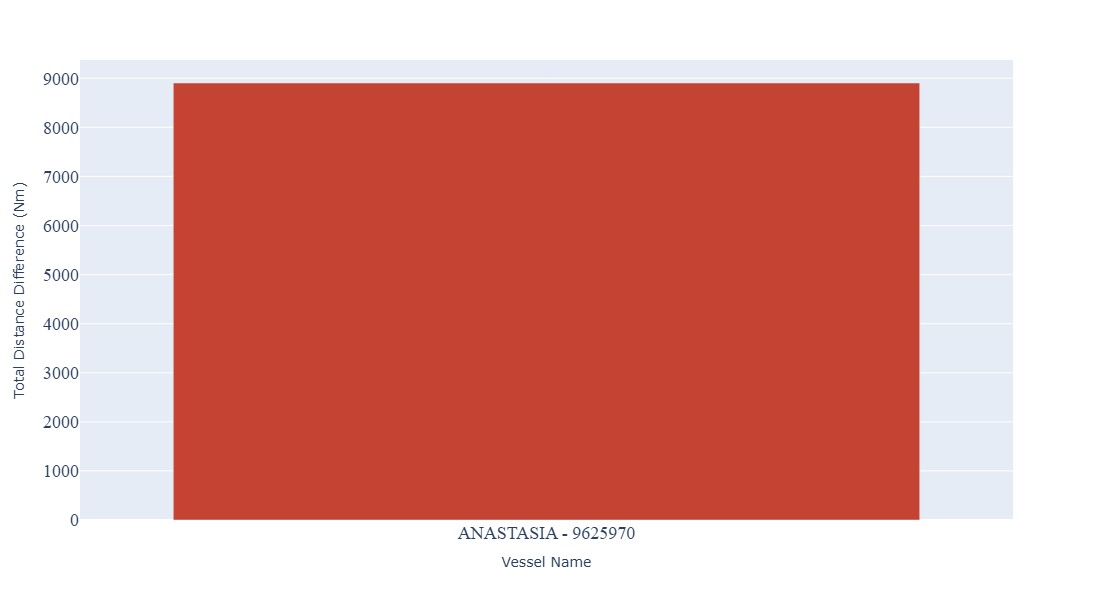

In [21]:
if report_type == 'vessel':
    vsl_name = pd.DataFrame.from_dict(s['vessel_data'])
    col_vsl = dict(zip(vsl_name['imo'], vsl_name['name']))
    #s = s['data']
    
    Table1 = pd.DataFrame.from_dict(s['data']['table1']['table1']).fillna(0)
    Table1['improvement'] = Table1['improvement'].astype(float).astype(int)
    Table1_str = Table1[['index', 'year1', 'year2', 'improvement']].astype(str)
    Table1_str['improvement'] = Table1_str['improvement'] + ' %'
    
    Table_1_head_Year = [['Year', first_Period, second_Period, '% Improvement']] if all((first_Period, second_Period)) else [['Year', str(first_Period_year), str(second_Period_year), '% Improvement']]
    Table_1_Year = Table_1_head_Year + Table1_str.values.tolist()
    
    # 2nd Table
    Table_2 = Table1.set_index(['index'])
    Table_2 = Table_2.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]].reset_index()
    
    Table_2 = Table_2.rename({'improvement': 'Improvement (%)', 'year1': first_Period, 'year2': second_Period, 'index': 'Year'}, axis=1) if all((first_Period, second_Period)) else Table_2.rename({'improvement': 'Improvement (%)', 'year1': str(first_Period_year), 'year2': str(second_Period_year), 'index': 'Year'}, axis=1)
    
    Table_2_new = Table_2.T.reset_index().T.set_index(0).T
    Table_2_str = Table_2_new.astype(str)
    
    
    MVG_Total_sum = 0
    MVG_Total_TEU_sum = 0
    
    mvg_year1 = pd.DataFrame.from_dict(s['data']['year1']['moving data average'])
    mvg_year2 = pd.DataFrame.from_dict(s['data']['year2']['moving data average'])
    
    if not mvg_year1.empty and not mvg_year2.empty:
        MVG_Total_sum = mvg_year1["EEOI For Cargo [MT]"].sum() + mvg_year2["EEOI For Cargo [MT]"].sum()
        Mvg_Legend_Year1 = f"{moving_average} Moving Avg {first_Period}" if all((first_Period, second_Period)) else f"{moving_average} Moving Avg {first_Period_year}"
        Mvg_Legend_Year2 = f"{moving_average} Moving Avg {second_Period}" if all((first_Period, second_Period)) else f"{moving_average} Moving Avg {second_Period_year}"
    
    
        # Moving Average - Graph 3
        trace1 = go.Scatter(
            x=mvg_year1["S.No"],
            y=mvg_year1["EEOI For Cargo [MT]"],
            mode='lines+markers',
            name=Mvg_Legend_Year1,
            line=dict(color='green', width=2),
            marker=dict(size=8)
        )
    
        trace2 = go.Scatter(
            x=mvg_year2["S.No"],
            y=mvg_year2["EEOI For Cargo [MT]"],
            mode='lines+markers',
            name=Mvg_Legend_Year2,
            line=dict(color='orange', width=2),
            marker=dict(size=8)
        )
    
        trace3 = go.Scatter(
            x=mvg_year1["S.No"],
            y=mvg_year1["EEOIGOALMT"],
            mode='lines',
            name='EEOI GOAL MT',
            line=dict(color='blue', width=2, dash='dash')
        )
    
        # Set layout
        layout = go.Layout(
            xaxis=dict(
                title=' ',
                tickfont=dict(size=13),
                showgrid=False  # Correct syntax for showgrid
            ),
            yaxis=dict(
                title='Moving Average',
                tickfont=dict(size=13),
                showgrid=False  # Correct syntax for showgrid
            ),
            showlegend=True,
            legend=dict(
                x=1,  # Adjust the x position of the legend
                y=1,  # Adjust the y position of the legend
                font=dict(size=10),  # Adjust the font size of the legend
                bgcolor='rgba(0, 0, 0, 0)'  # Make the legend background transparent
            ),
            width=1000,
            height=500
        )
    
        # Create figure
        fig = go.Figure(data=[trace1, trace2, trace3], layout=layout)
    
        fig.show()
        plot_div3 = pyo.plot(fig, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})
    
        MVG_Total_TEU_sum = mvg_year1["EEOI For Cargo [TEU]"].sum() + mvg_year2["EEOI For Cargo [TEU]"].sum()
    
        Mvg_Legend_Year1 = f"{moving_average} Moving Avg {first_Period}" if all((first_Period, second_Period)) else f"{moving_average} Moving Avg {first_Period_year}"
        Mvg_Legend_Year2 = f"{moving_average} Moving Avg {second_Period}" if all((first_Period, second_Period)) else f"{moving_average} Moving Avg {second_Period_year}"
    
        if mvg_year1.empty and mvg_year2.empty:
            print('No Data Available')
        else:
            pass
    
        # Moving average graph 4
        trace1 = go.Scatter(
            x=mvg_year1["S.No"],
            y=mvg_year1["EEOI For Cargo [TEU]"],
            mode='lines+markers',
            name=Mvg_Legend_Year1,
            line=dict(color='green', width=2),
            marker=dict(size=8)
        )
    
        trace2 = go.Scatter(
            x=mvg_year2["S.No"],
            y=mvg_year2["EEOI For Cargo [TEU]"],
            mode='lines+markers',
            name=Mvg_Legend_Year2,
            line=dict(color='orange', width=2),
            marker=dict(size=8)
        )
    
        trace3 = go.Scatter(
            x=mvg_year1["S.No"],
            y=mvg_year1["EEOIGOALTEU"],
            mode='lines',
            name='EEOI GOAL TEU',
            line=dict(color='blue', width=2, dash='dash')
        )
    
        # Set layout
        layout = go.Layout(
            xaxis=dict(
                title=' ',
                tickfont=dict(size=13),
                showgrid=False  # Correct syntax for showgrid
            ),
            yaxis=dict(
                title='Moving Average',
                tickfont=dict(size=13),
                showgrid=False  # Correct syntax for showgrid
            ),
            showlegend=True,
            legend=dict(
                x=1,  # Adjust the x position of the legend
                y=1,  # Adjust the y position of the legend
                font=dict(size=12),  # Adjust the font size of the legend
                bgcolor='rgba(0, 0, 0, 0)'  # Make the legend background transparent
            ),
            width=1000,
            height=500
        )
    
        fig = go.Figure(data=[trace1, trace2, trace3], layout=layout)
    
        fig.show()
        plot_div4 = pyo.plot(fig, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})
    
    else:
        print('No Data Available')
    
    Year1_Graph = pd.DataFrame.from_dict(s['data']['year1']['finaldata']).round(2)
    Year2_Graph = pd.DataFrame.from_dict(s['data']['year2']['finaldata']).round(2)
    EEOI_Analysis = Table1.set_index(['index'])
    EEOI_Analysis = EEOI_Analysis.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]]
    EEOI_Analysis = EEOI_Analysis[['year1', 'year2']]
    
    EEOI_Analysis_new = EEOI_Analysis.rename({"year1": first_Period, 'year2': second_Period}, axis=1) if all((first_Period, second_Period)) else EEOI_Analysis.rename({"year1": str(first_Period_year), 'year2': str(second_Period_year)}, axis=1)
    
    # EEOI_Analysis_Graph = EEOI_Analysis_new.plot.bar(rot=0, color={first_Period: "#588aee", second_Period: "#61d8a8"}, width=0.8, figsize=(10, 6))
    
    EEOI_Analysis = Table1.set_index(['index'])
    EEOI_Analysis = EEOI_Analysis.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]]
    EEOI_Analysis = EEOI_Analysis[['year1', 'year2']]
    
    EEOI_Analysis_1 = EEOI_Analysis_new.columns[0]
    EEOI_Analysis_2 = EEOI_Analysis_new.columns[1]
    
    # Create a bar chart for each trace with values above the bars
    trace1 = go.Bar(
        x=EEOI_Analysis.index,
        y=EEOI_Analysis['year1'],
        text=EEOI_Analysis['year1'].round(2),  # Adjust rounding as needed
        textposition='outside',  # Display text labels outside the bars
        name=EEOI_Analysis_1,
        marker=dict(color="#588aee")
    )
    
    trace2 = go.Bar(
        x=EEOI_Analysis.index,
        y=EEOI_Analysis['year2'],
        text=EEOI_Analysis['year2'].round(2),
        textposition='outside',
        name=EEOI_Analysis_2,  # Use the dynamically generated legend label
        marker=dict(color="#61d8a8")
    )
    
    layout = go.Layout(
        xaxis=dict(
            title=' ',
            tickfont=dict(size=17),
            showgrid=False  # Correct syntax for showgrid
        ),
        yaxis=dict(
            title='Value',
            tickfont=dict(size=17),
            showgrid=False  # Correct syntax for showgrid
        ),
        showlegend=True,
        legend=dict(
            x=1,  # Adjust the x position of the legend
            y=1,  # Adjust the y position of the legend
            font=dict(size=15),  # Adjust the font size of the legend
            bgcolor='rgba(0, 0, 0, 0)'  # Make the legend background transparent
        ),
        width=1050,
        height=600
    )
    
    fig = go.Figure(data=[trace1, trace2], layout=layout)
    fig.show()
    plot_div = pyo.plot(fig, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})
    
    Improvement_Percent = Table1.set_index(['index'])
    Improvement_Percent = Improvement_Percent.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]]
    Improvement_Percent = Improvement_Percent[['improvement']].reset_index()
    Improvement_Percent = Improvement_Percent.set_index(['index'])
    
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        x=Improvement_Percent.index,
        y=Improvement_Percent['improvement'],
        text=Improvement_Percent['improvement'].astype('str') + '%',
        textposition='outside',  # Display text outside the bar
        marker=dict(color='#808080')  
    ))
    
    layout = go.Layout(
        xaxis=dict(
            title='',
            tickfont=dict(size=17),
            showgrid=False  # Correct syntax for showgrid
        ),
        yaxis=dict(
            title='% Improvement',
            tickfont=dict(size=17),
            showgrid=False  # Correct syntax for showgrid
        ),
        showlegend=False,
        width=1000,
        height=600
    )
    # Format y-axis tick labels as percentages
    layout['yaxis']['tickformat'] = '.3f%'
    fig.update_layout(layout)
    #fig.show()
    plot_div2 = pyo.plot(fig, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})
    
    #total cargo
    Total_Cargo = Year1_Graph[['imo', 'cargomt']]
    
    if second_Period:
        Total_Cargo[second_Period] = Total_Cargo['imo'].map(Year2_Graph.set_index('imo')['cargomt'])
        Total_Cargo = Total_Cargo.sort_values(by=second_Period)
    else:
        Total_Cargo[str(second_Period_year)] = Total_Cargo['imo'].map(Year2_Graph.set_index('imo')['cargomt'])
        Total_Cargo = Total_Cargo.sort_values(by=str(second_Period_year))
    Total_Cargo['Vessel Name'] = Total_Cargo['imo'].map(col_vsl)
    Total_Cargo['Vessel - IMO'] = Total_Cargo['Vessel Name']
    
    if first_Period:
        Total_Cargo = Total_Cargo.rename({'cargomt': first_Period}, axis=1)
        melted_data = pd.melt(Total_Cargo, id_vars=['Vessel - IMO'], value_vars=[first_Period, second_Period] if second_Period else [first_Period], var_name='Year', value_name='Total_Cargo')
    else:
        Total_Cargo = Total_Cargo.rename({'cargomt': str(first_Period_year)}, axis=1)
        melted_data = pd.melt(Total_Cargo, id_vars=['Vessel - IMO'], value_vars=[str(first_Period_year), str(second_Period_year)] if second_Period else [str(first_Period_year)], var_name='Year', value_name='Total_Cargo')
    # Drop rows with NaN values in 'Total_Cargo'
    melted_data.dropna(subset=['Total_Cargo'], inplace=True)
    Total_Cargo_Graph = px.bar(
        melted_data,
        x='Vessel - IMO',
        y='Total_Cargo',
        color='Year',
        barmode='group', 
        color_discrete_sequence=['#c44332', '#1a75c1'] if second_Period else ['#c44332'],
        labels={'Total_Cargo': 'Total Cargo (metric-Tonne)'},
        title='Total Cargo',
    )
    layout_total_cargo = go.Layout(
        title=dict(
            text='Total Cargo',
            font=dict(size=20, family='Roboto, sans-serif', color='black'),
            x=0.5
        ),
        xaxis=dict(
            title='Vessel Name',
            tickfont=dict(size=18, family='Roboto, sans-serif'),
            showgrid=False
        ),
        yaxis=dict(
            title='Total Cargo (metric-Tonne)',
            tickfont=dict(size=18, family='Roboto, sans-serif'),
            showgrid=False
        ),
        legend=dict(
            title='',
            font=dict(size=15),
            bgcolor='rgba(0, 0, 0, 0)'
        ),
        width=1050,
        height=650
    )
    Total_Cargo_Graph.update_layout(layout_total_cargo)
    Total_Cargo_Graph.show()
    plot_div7 = pyo.plot(Total_Cargo_Graph, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})
    
    
     
    if second_Period:
        Total_Cargo['Difference'] = Total_Cargo[second_Period] - Total_Cargo[first_Period]
    else:
        Total_Cargo['Difference'] = Total_Cargo[str(second_Period_year)] - Total_Cargo[str(first_Period_year)]
    
    Total_Cargo = Total_Cargo.sort_values(by='Difference', ascending=False)
    
    
    # Plotly bar chart for Total Cargo - Period wise difference
    Total_Cargo_diff_graph = px.bar(
        Total_Cargo,
        x='Vessel - IMO',
        y='Difference',
        barmode='group', 
        color_discrete_sequence=['#c44332'],
        labels={'Difference': 'Total Cargo Difference (metric-Tonne)'},
    )
    
    # Update the layout
    Total_Cargo_diff_graph.update_layout(
        xaxis=dict(title='Vessel Name', tickfont=dict(size=18, family='Times New Roman')),
        yaxis=dict(title='Total Cargo Difference (metric-Tonne)', tickfont=dict(size=18, family='Times New Roman')),
        showlegend=False,
        width=1000,
        height=600
    )
    
    # Show the figure
    Total_Cargo_diff_graph.show()
    plot_div8 = pyo.plot(Total_Cargo_diff_graph, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})
    
    
    # Total Distance
    Total_Distance = Year1_Graph[['imo', 'average_distance']]
    
    if second_Period:
        Total_Distance[second_Period] = Total_Distance['imo'].map(Year2_Graph.set_index('imo')['average_distance'])
        Total_Distance = Total_Distance.sort_values(by=second_Period)
    else:
        Total_Distance[str(second_Period_year)] = Total_Distance['imo'].map(Year2_Graph.set_index('imo')['average_distance'])
        Total_Distance = Total_Distance.sort_values(by=str(second_Period_year))
    
    Total_Distance['Vessel Name'] = Total_Distance['imo'].map(col_vsl)
    Total_Distance['Vessel - IMO'] = Total_Distance['Vessel Name']
    
    if first_Period:
        Total_Distance = Total_Distance.rename({'average_distance': first_Period}, axis=1)
        melted_data = pd.melt(Total_Distance, id_vars=['Vessel - IMO'], value_vars=[first_Period, second_Period] if second_Period else [first_Period], var_name='Year', value_name='Total_Distance')
    else:
        Total_Distance = Total_Distance.rename({'average_distance': str(first_Period_year)}, axis=1)
        melted_data = pd.melt(Total_Distance, id_vars=['Vessel - IMO'], value_vars=[str(first_Period_year), str(second_Period_year)] if second_Period else [str(first_Period_year)], var_name='Year', value_name='Total_Distance')
    
    # Drop rows with NaN values in 'Total_Distance'
    melted_data.dropna(subset=['Total_Distance'], inplace=True)
    
    Total_Distance_Graph = px.bar(
        melted_data,
        x='Vessel - IMO',
        y='Total_Distance',
        color='Year',
        barmode='group', 
        color_discrete_sequence=['#c44332', '#1a75c1'],
        labels={'Total_Distance': 'Total Distance (Nm)'},
        title='Total Distance',
    )
    
    layout_total_distance = go.Layout(
        title=dict(
            text='Total Distance',
            font=dict(size=20, family='Roboto, sans-serif', color='black'),
            x=0.5
        ),
        xaxis=dict(
            title='Vessel Name',
            tickfont=dict(size=18, family='Roboto, sans-serif'),
            showgrid=False
        ),
        yaxis=dict(
            title='Total Distance (Nm)',
            tickfont=dict(size=18, family='Roboto, sans-serif'),
            showgrid=False
        ),
        legend=dict(
            title='',
            font=dict(size=15),
            bgcolor='rgba(0, 0, 0, 0)'
        ),
        width=1000,
        height=600
    )
    
    Total_Distance_Graph.update_layout(layout_total_distance)
    Total_Distance_Graph.show()
    plot_div9 = pyo.plot(Total_Distance_Graph, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})
    
    
            # Total Distance Period Wise Difference
    if (first_Period and second_Period) != None:
        Total_Distance['Difference'] = Total_Distance[second_Period] - Total_Distance[first_Period]
    else:
        Total_Distance['Difference'] = Total_Distance[str(second_Period_year)] - Total_Distance[str(first_Period_year)]
    
    
    Total_Distance = Total_Distance.sort_values(by='Difference', ascending=False)
    
    
    
    # Plotly bar chart for Total Distance Period Wise Difference
    Total_Distance_diff_graph = px.bar(
        Total_Distance,
        x='Vessel - IMO',
        y='Difference',
        barmode='group', 
        labels={'Difference': 'Total Distance Difference (Nm)'},
        color_discrete_sequence=['#c44332'] * len(Total_Distance),  # Assign the color to each bar
    )
    
    # Update the layout
    Total_Distance_diff_graph.update_layout(
        xaxis=dict(title='Vessel Name', tickfont=dict(size=18, family='Times New Roman')),
        yaxis=dict(title='Total Distance Difference (Nm)', tickfont=dict(size=18, family='Times New Roman')),
        showlegend=False,
        width=1000,
        height=600
    )
    
    # Save or display the figure
    Total_Distance_diff_graph.show()
    plot_div10 = pyo.plot(Total_Distance_diff_graph, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})

else:
    pass

In [ ]:

html_table = "<table border='1'>\n"
# Create table header
html_table += "<tr>"
for col in Table_1_Year[0]:
    html_table += f"<th>{col}</th>"
html_table += "</tr>\n"

# Iterate over rows
for row in Table_1_Year[1:]:
    html_table += "<tr>"
    for value in row:
        html_table += f"<td>{value}</td>"
    html_table += "</tr>\n"

html_table += "</table>"

html_table2 = "<table border='1'>\n"
# Create table header
html_table2 += "<tr>"
for col in Table_2_new.columns:
    html_table2 += f"<th>{col}</th>"
html_table2 += "</tr>\n"

# Iterate over rows
for index, row in Table_2_new.iterrows():
    html_table2 += "<tr>"
    for value in row:
        html_table2 += f"<td>{value}</td>"
    html_table2 += "</tr>\n"

html_table2 += "</table>"

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title> YEAR 2023-2024 EEOI ANALYSIS </title>
    <style>
        body {{
            text-align: center;
            font-family: 'Roboto', sans-serif;
            color: #333;
            background-color: #fff;
        }}
        h1 {{
            color: #193185;
            font-size: 36px;
            margin-bottom: 20px;
        }}
        h2{{
            color: #193185;
            font-size: 30px; 

        }}
        img {{
            width: 100px;
            float: right;
        }}
        .info {{
            text-align: left;
            margin-left: 20px;
            display: flex;
            font-size: 16px;
            font-weight: bold;
        }}

        .second-info{{ margin-left: 100px;}}
        table {{
            margin: 20px auto;
                width: 65%;
                border-collapse: collapse;
                border: solid;

        }}

            table, tr, td {{height: 30px;
                border: 1px solid;
            }}
        .plot_div{{
                    width: 100%;
                    display: flex;
                    justify-content: center;
        }}

        hr {{
            border-width: 3px;
            border-color: #33;
            margin-top: 20px;
            border-style: solid; /* Add border style */
        }}


        th {{
    background: blue;
    color: white;
    height: 41px;
}}
    </style>
</head>
<body>
    <br>
    <br>
    {image_tag}
    
    <br>
    <br>
    <br>
    <h1>YEAR 2023-2024 EEOI ANALYSIS </h1>  
    <hr>
    <br>
    <div class="info">
        <div class='first-info'>
        <p>Fleet:{fleet}</p>
        {
            "<p>First Period: "+ first_Period + "</p><p> Second Period: " + second_Period + "</p>" if first_Period and second_Period != 'null' else
            "<p>First Period: " + first_period_min + " to " + first_period_max  + "</p>"
            "<p>Second Period: " + second_period_min + " to " + second_period_max + "</p>"}        
        </div>
    </div>
    <hr>
    <br>
    {html_table}
    <br>
    <h2>YEARLY EEOI ANALYSIS</h2>
    <!-- Add the centered and bigger table -->
    <br>
    {html_table2}
    <br>
    <br>
    <br>
    <h2>EEOI ANALYSIS</h2>
    <div class="plot_div">
        {plot_div}
    </div>
    <br>
    <br>
    <h2>YEARLY % IMPROVEMENT- EEOI ANALYSIS</h2>
    <div class="plot_div">
        {plot_div2}
    </div>
    <br>
    <br>
    <h2>ENERGY EFFICENCY (GM/TONNE-MILE)</h2>
    <div class="plot_div">
        {plot_div5}
    </div>
    <br>
    <br>
    <h2>TOTAL CARGO</h2>
    <div class="plot_div">
        {plot_div7}
    </div>

    <h2>TOTAL DISATNCE</h2>
    <div class="plot_div">
        {plot_div9}
    </div>
    <br>
</body>
</html>
"""
print("fleeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeet")
print("fleeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeet",report_type)